In [2]:
# Get daily constraint ranked by the abs RT - DA 
from functions import (
    get_recent_constraint_mvalue,
    get_node_dfax_from_constraint_num,
    get_hourly_mvalue_for_constraint_num,
    get_constraint_node_prices_from_constraint_num,
    get_constraints_node_price,
    get_metrics_for_nodes,
    get_recent_direction_accuracy,
    get_weather_date,
    predict_tomorrow_percentile,
    analyze_constraint_by_zone,
    plot_constraint_seasonality,
    plot_recent_hourly_distribution,
)
import pandas as pd

In [3]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-06-17


In [4]:
dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
mvalue= get_recent_constraint_mvalue(dt, dt)
dfax= get_node_dfax_from_constraint_num(mvalue)
hourly_mvalue = get_hourly_mvalue_for_constraint_num(mvalue)
fundamentals = get_weather_date(hourly_mvalue, dt)

start_dt: 2026-06-16, end_dt: 2026-06-16, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 0, DA constraints: 70
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,776592,0,-2350.0661,2350.0661,2350.0661,xfmrduncan-duncan,wfec:anadarkofletch3comanch2:138
1,509581,0,-1447.5790,1447.5790,1447.5790,lngord-maiz,wr:wichbent:345:1:8
2,649753,0,-1319.7078,1319.7078,1319.7078,lnrussett-sbrown,okge:brown2bodlecaney1:138:7:34
10,826289,0,-440.0245,440.0245,440.0245,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:


RT active constraint-days: 0
DA active constraint-days: 821
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue     rt_da
0               509581  2024-06-21  12          0   -65.1176   65.1176
1               509581  2024-06-21  13          0  -112.7582  112.7582
2               509581  2024-06-21  14          0  -207.4499  207.4499
3               509581  2024-06-21  15          0  -141.8997  141.8997
4               509581  2024-06-21  16          0  -158.8748  158.8748

Merged hourly rows: 8270


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,509581,2024-06-21,12,0,-65.1176,65.1176,lngord-maiz,wr:wichbent:345:1:8
1,509581,2024-06-21,13,0,-112.7582,112.7582,lngord-maiz,wr:wichbent:345:1:8
2,509581,2024-06-21,14,0,-207.4499,207.4499,lngord-maiz,wr:wichbent:345:1:8
3,509581,2024-06-21,15,0,-141.8997,141.8997,lngord-maiz,wr:wichbent:345:1:8
4,509581,2024-06-21,16,0,-158.8748,158.8748,lngord-maiz,wr:wichbent:345:1:8
...,...,...,...,...,...,...,...,...
8265,826289,2026-06-14,12,0,-260.8429,260.8429,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:
8266,826289,2026-06-14,13,0,-240.8705,240.8705,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:
8267,826289,2026-06-14,14,0,-60.8099,60.8099,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:
8268,826289,2026-06-15,23,0,-107.2641,107.2641,xfmrduncan-duncan,okgecsws:sunnysdeterry_rd:345:2:


Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


monitored
lngord-maiz          1069
xfmrduncan-duncan    1599
lnrussett-sbrown     5602


Constraint  : 'lngord-maiz'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0614  |  Total hours: 17400


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lngord-maiz,4,rz4_spp_res_zonal_load_forecast_f,0.0614,0.1241,1.02
0,lngord-maiz,4,rz4_spp_res_zonal_wind_forecast_f,0.0614,0.0517,-0.16


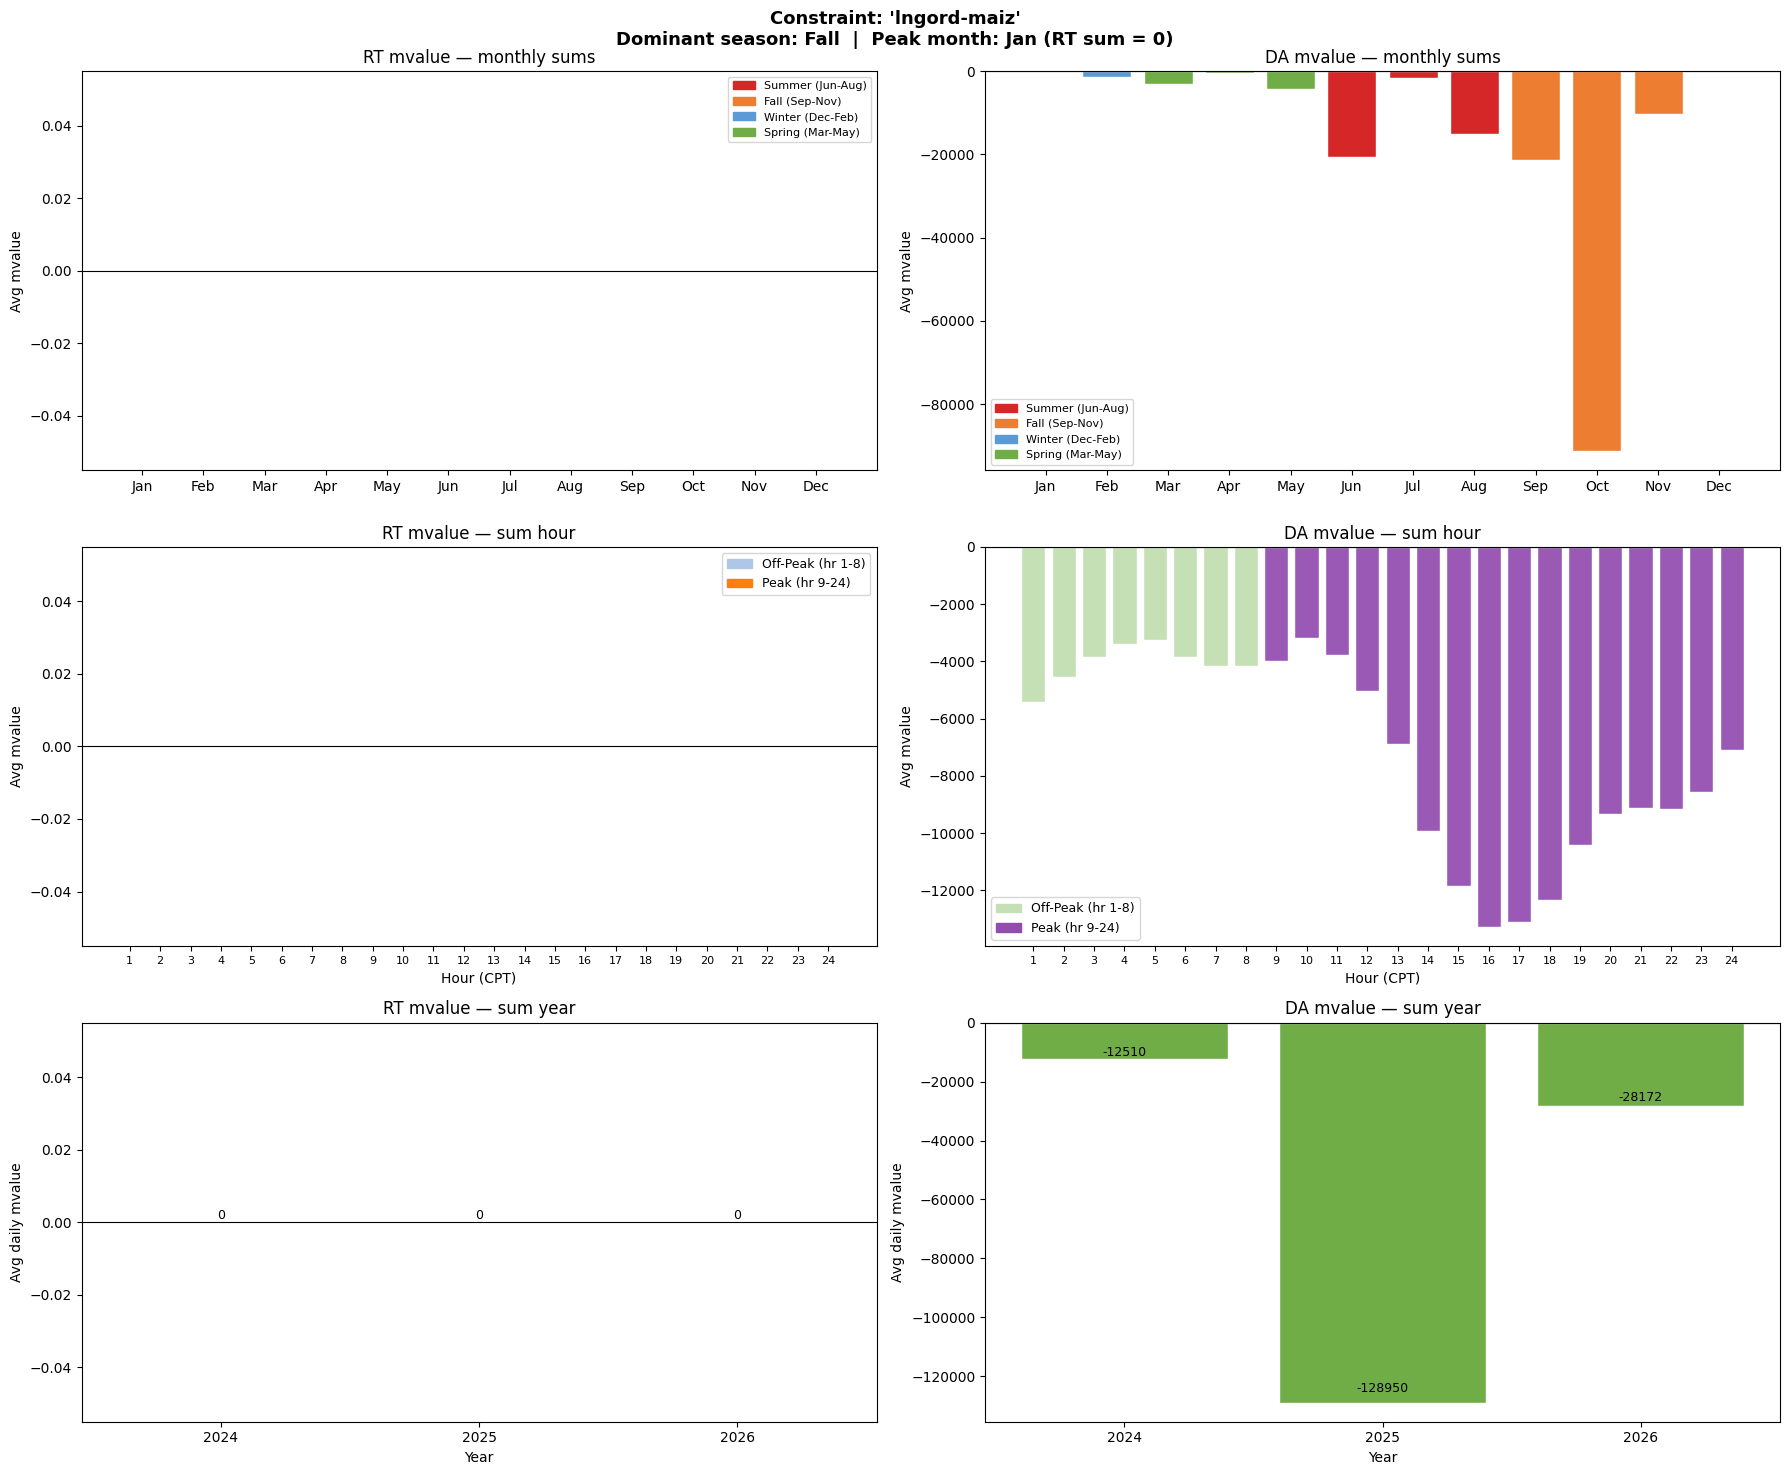

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -137006.68  |  off-peak (hr 1-8):  -32625.30
'lngord-maiz'  |  2026-06-05 → 2026-06-15  |  10 days


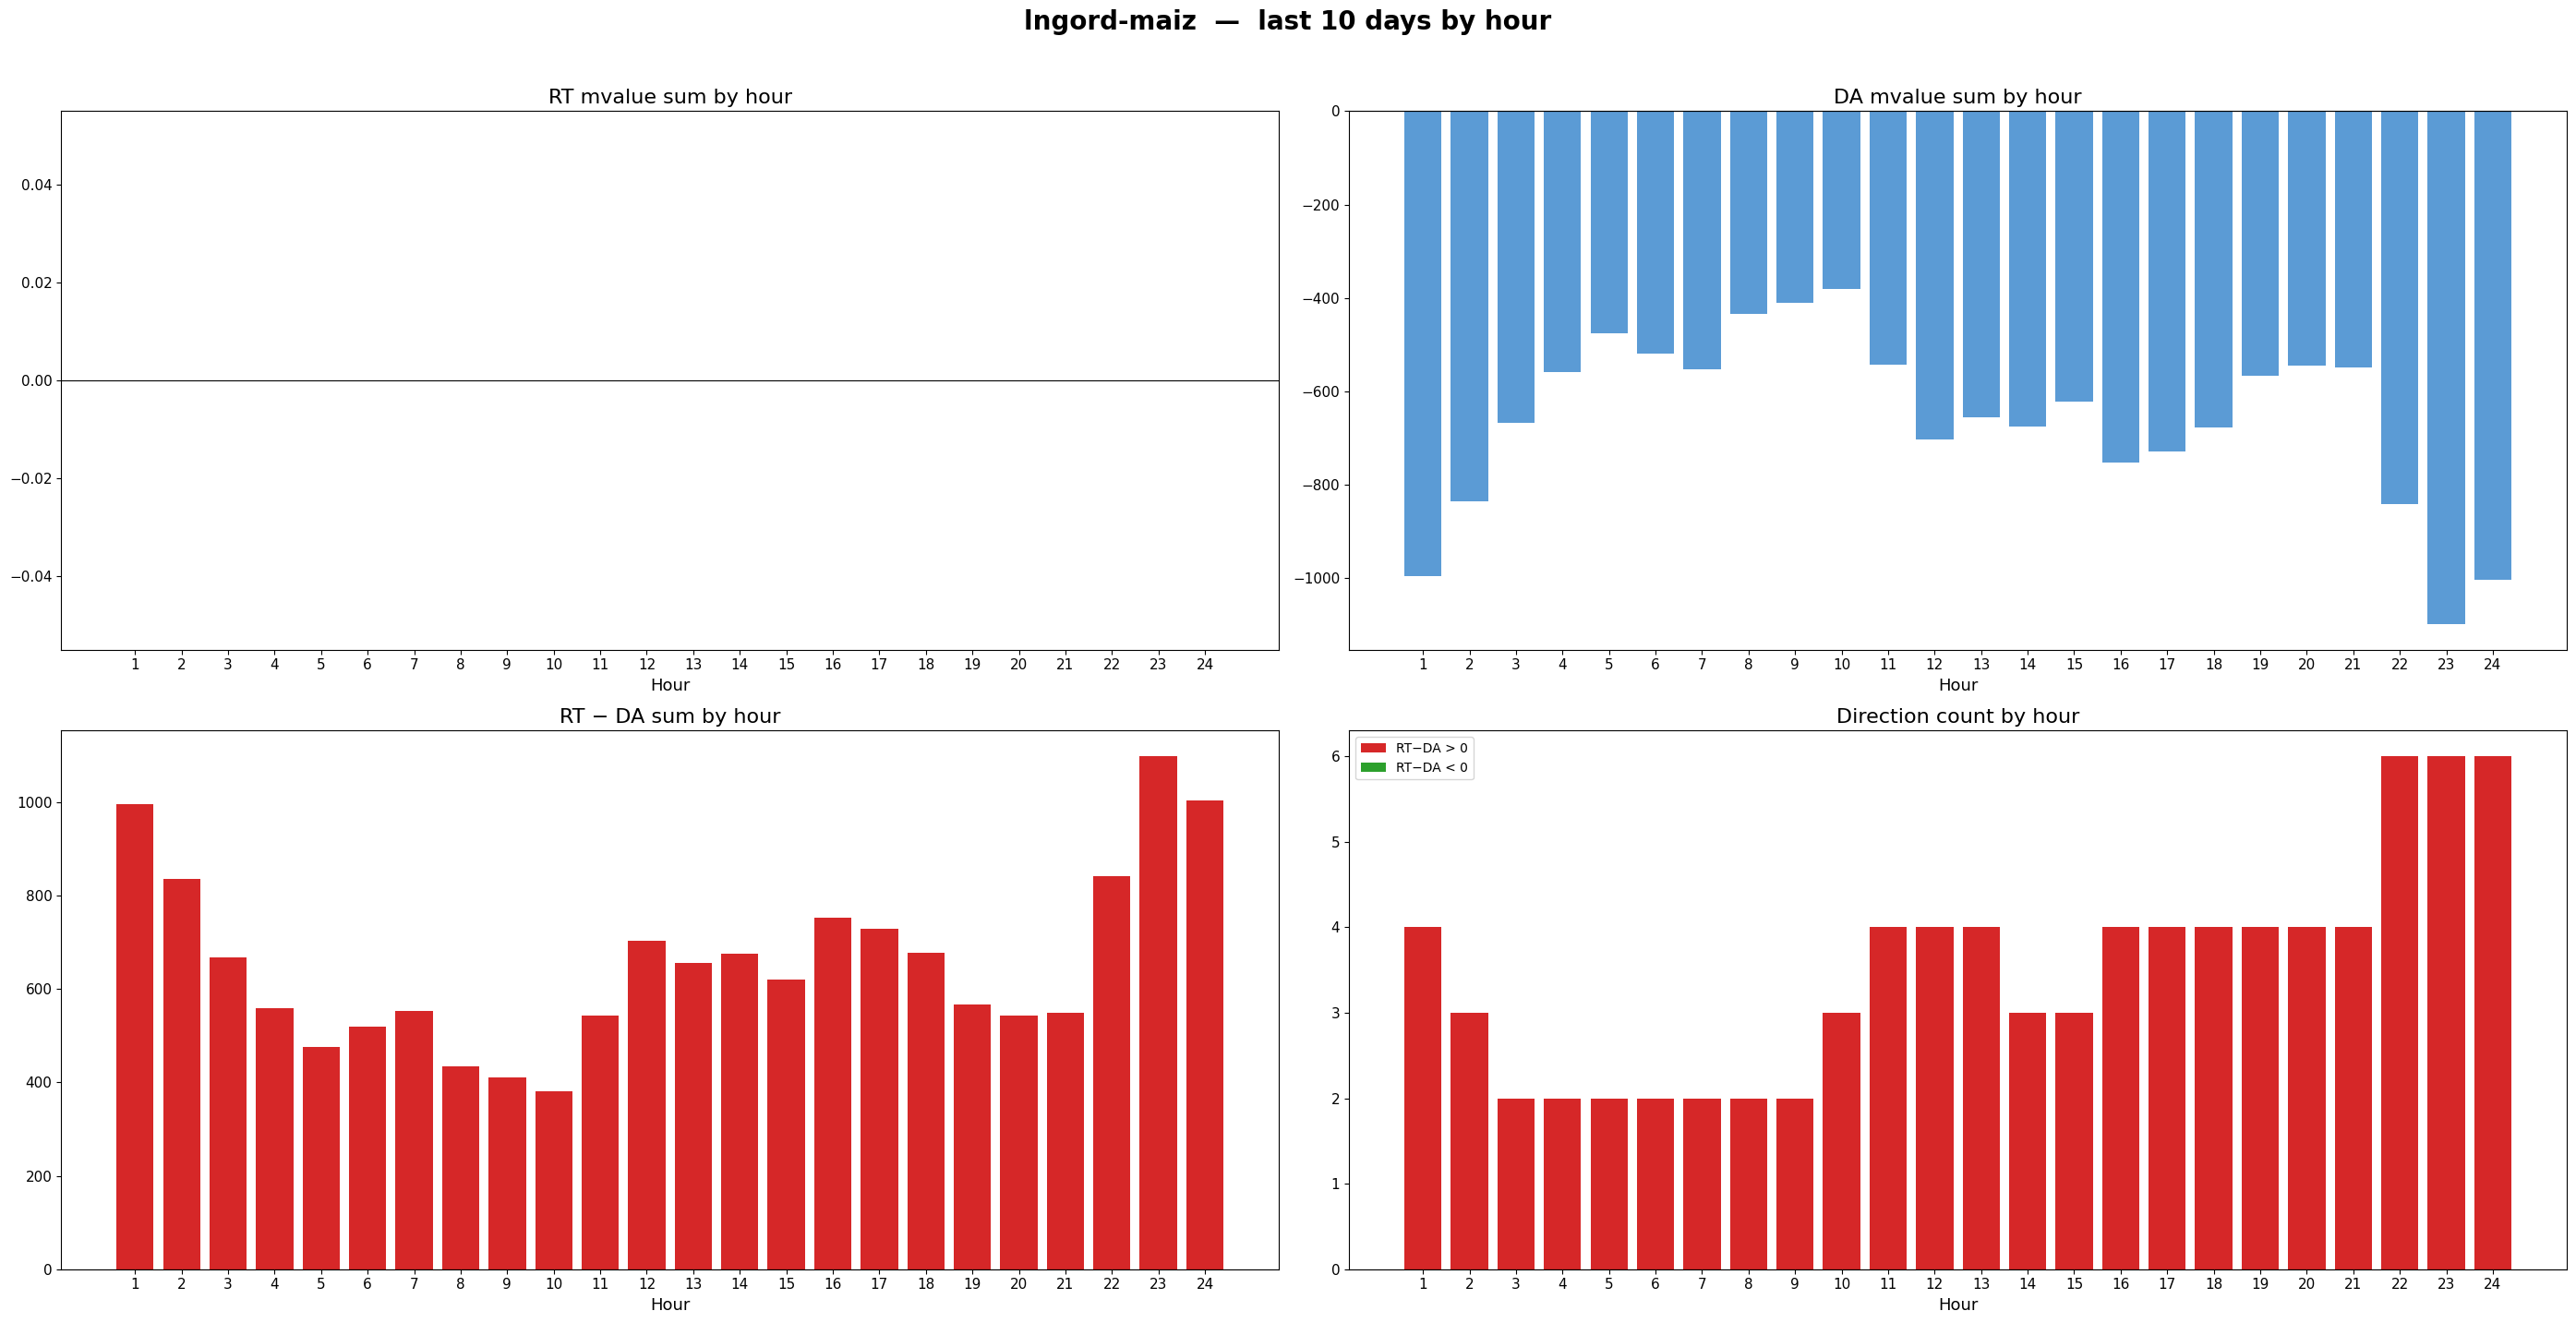


Total rows: 126142

  lngord-maiz


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1504,0.3268,0.411783,0.783217,-28.589762,-19.815584,143.0
1,1502,0.1168,0.402561,0.804196,-10.218128,-13.449349,143.0
2,1505,0.0898,0.376520,0.804196,-7.856061,-12.387486,143.0
3,1465,0.1524,0.356394,0.783217,-13.332557,-13.258262,143.0
4,1464,0.1667,0.333104,0.776224,-14.583578,-13.170856,143.0
...,...,...,...,...,...,...,...
113,1374,-0.0712,NaN,NaN,NaN,NaN,0.0
114,1376,0.1612,NaN,NaN,NaN,NaN,0.0
115,1377,-0.0991,NaN,NaN,NaN,NaN,0.0
116,1379,0.1533,NaN,NaN,NaN,NaN,0.0


Constraint  : 'xfmrduncan-duncan'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0914  |  Total hours: 17400


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,xfmrduncan-duncan,4,rz4_spp_res_zonal_wind_forecast_f,0.0914,0.2621,1.87
1,xfmrduncan-duncan,4,rz4_spp_res_zonal_load_forecast_f,0.0914,0.1115,0.22


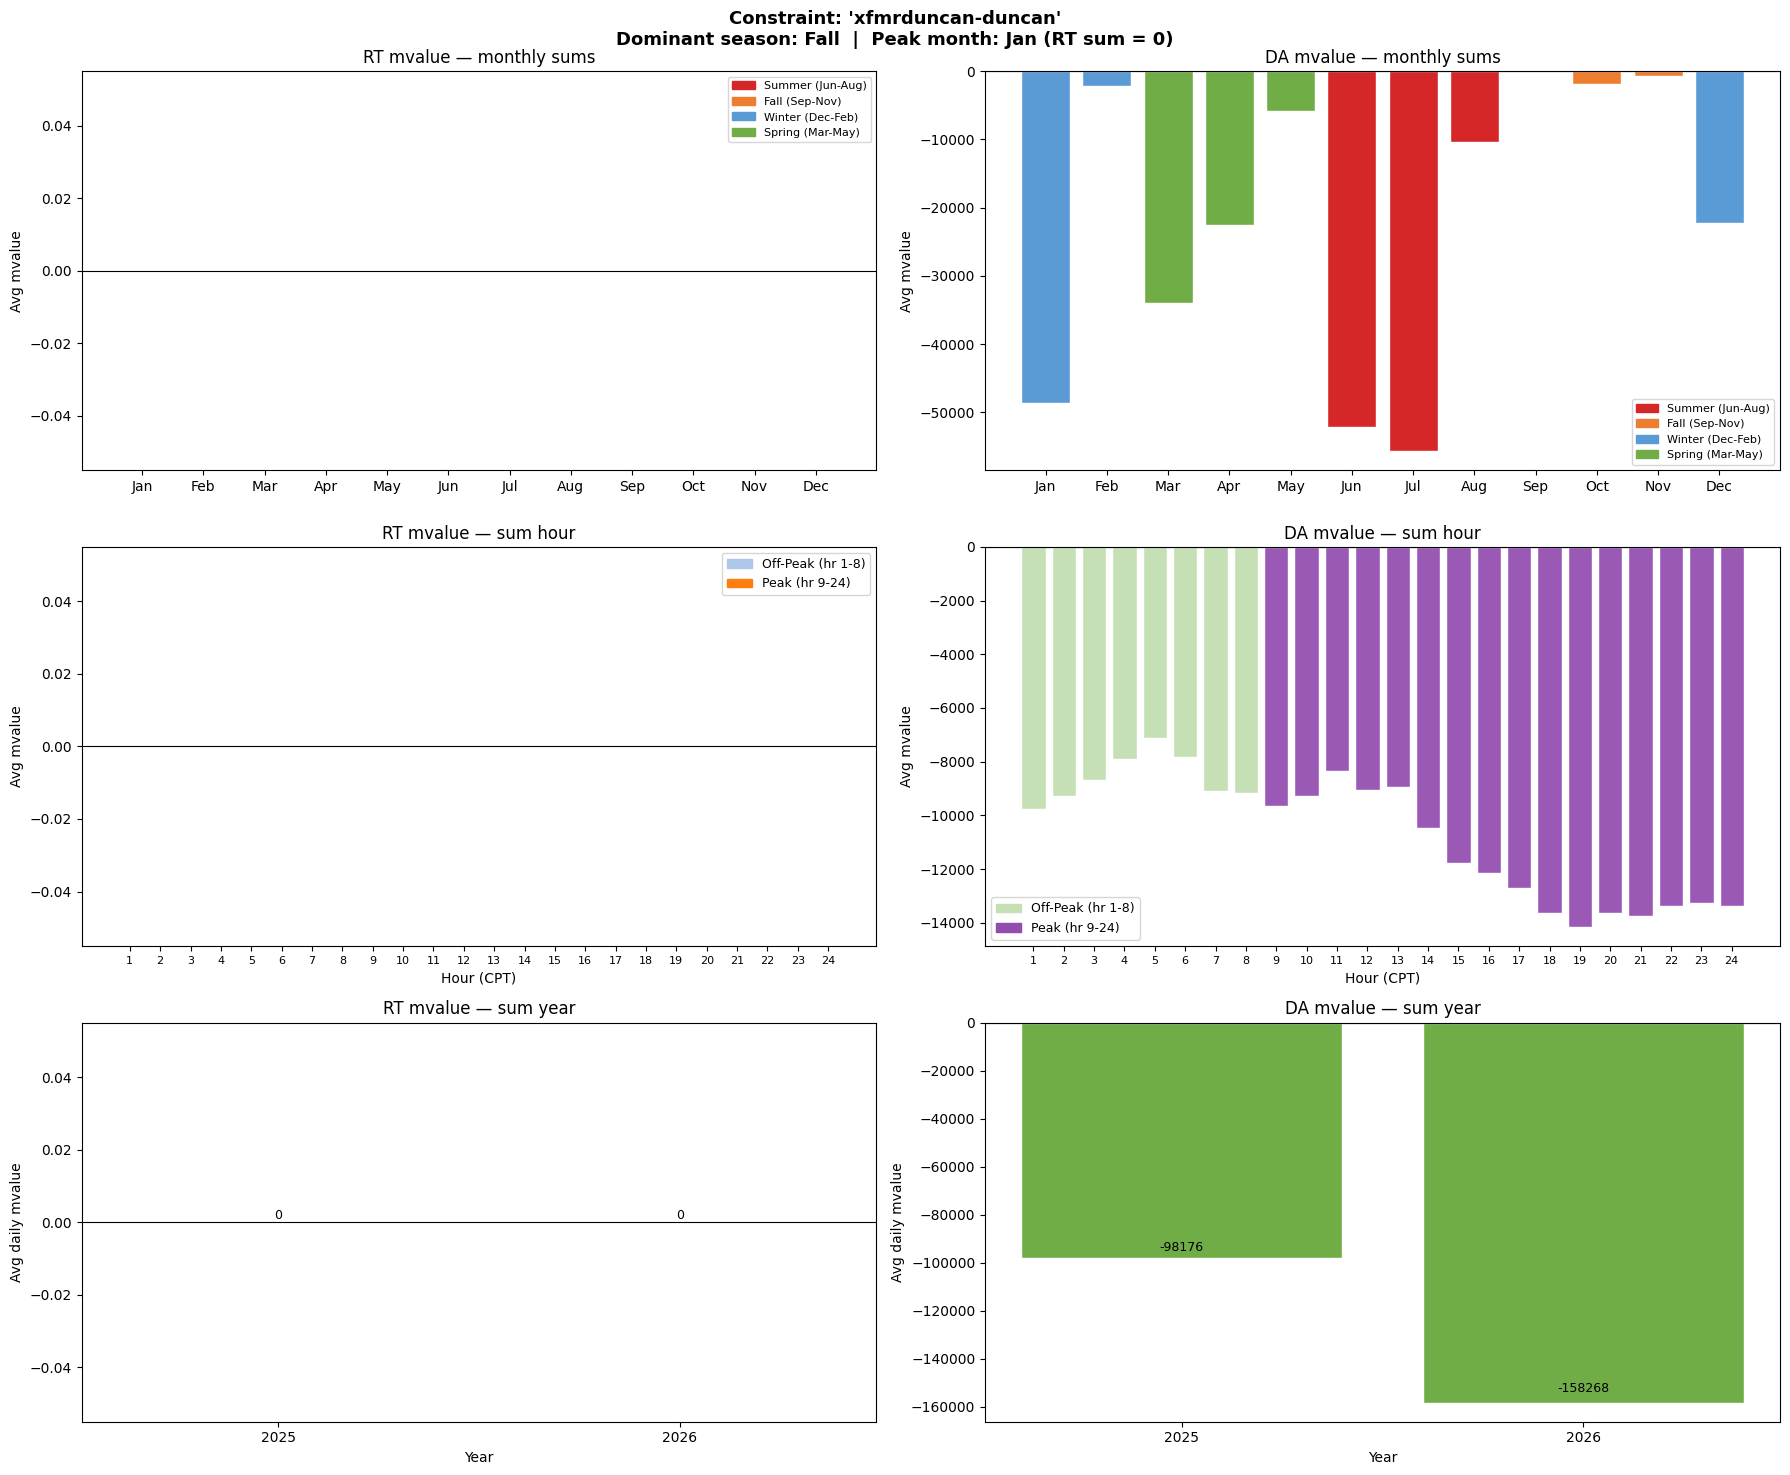

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -187613.24  |  off-peak (hr 1-8):  -68830.81
'xfmrduncan-duncan'  |  2026-06-05 → 2026-06-15  |  11 days


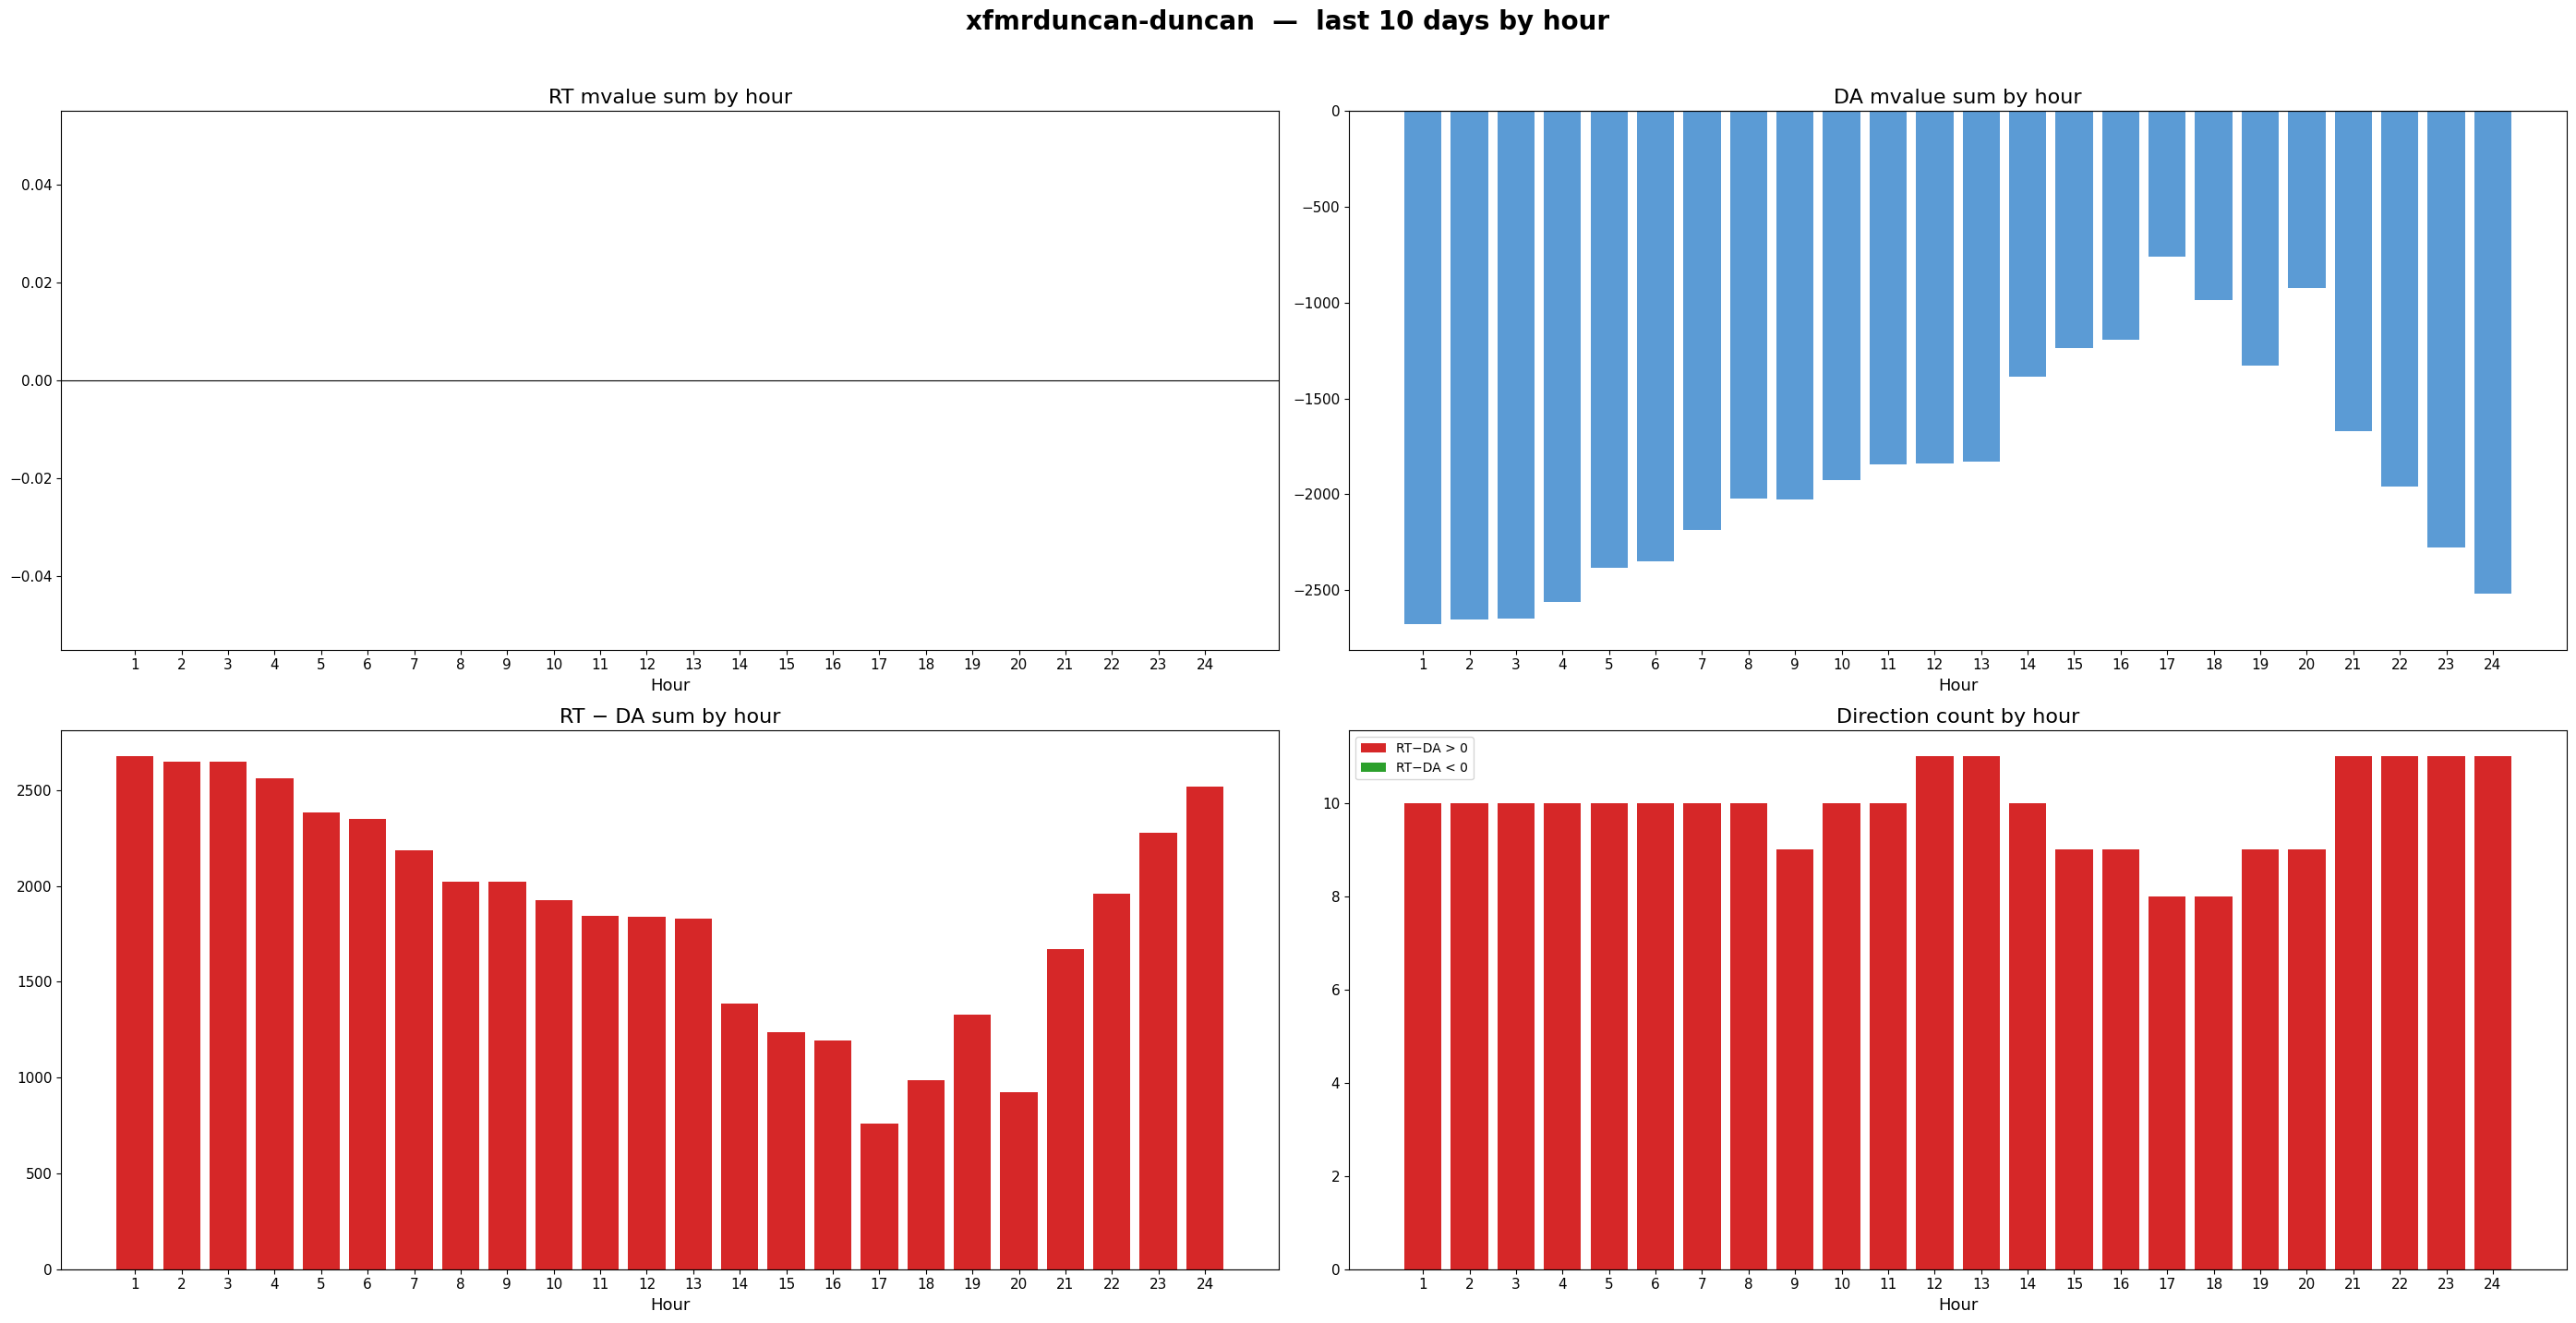


Total rows: 2469

  xfmrduncan-duncan


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1715,0.7652,0.238725,0.772169,-79.732024,-10.341727,1466.0
1,1039,-0.0640,0.027319,0.527650,9.071161,0.338465,868.0


Constraint  : 'lnrussett-sbrown'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.3220  |  Total hours: 17400


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnrussett-sbrown,4,rz4_spp_res_zonal_wind_forecast_f,0.322,0.6609,1.05
1,lnrussett-sbrown,4,rz4_spp_res_zonal_load_forecast_f,0.322,0.1575,-0.51


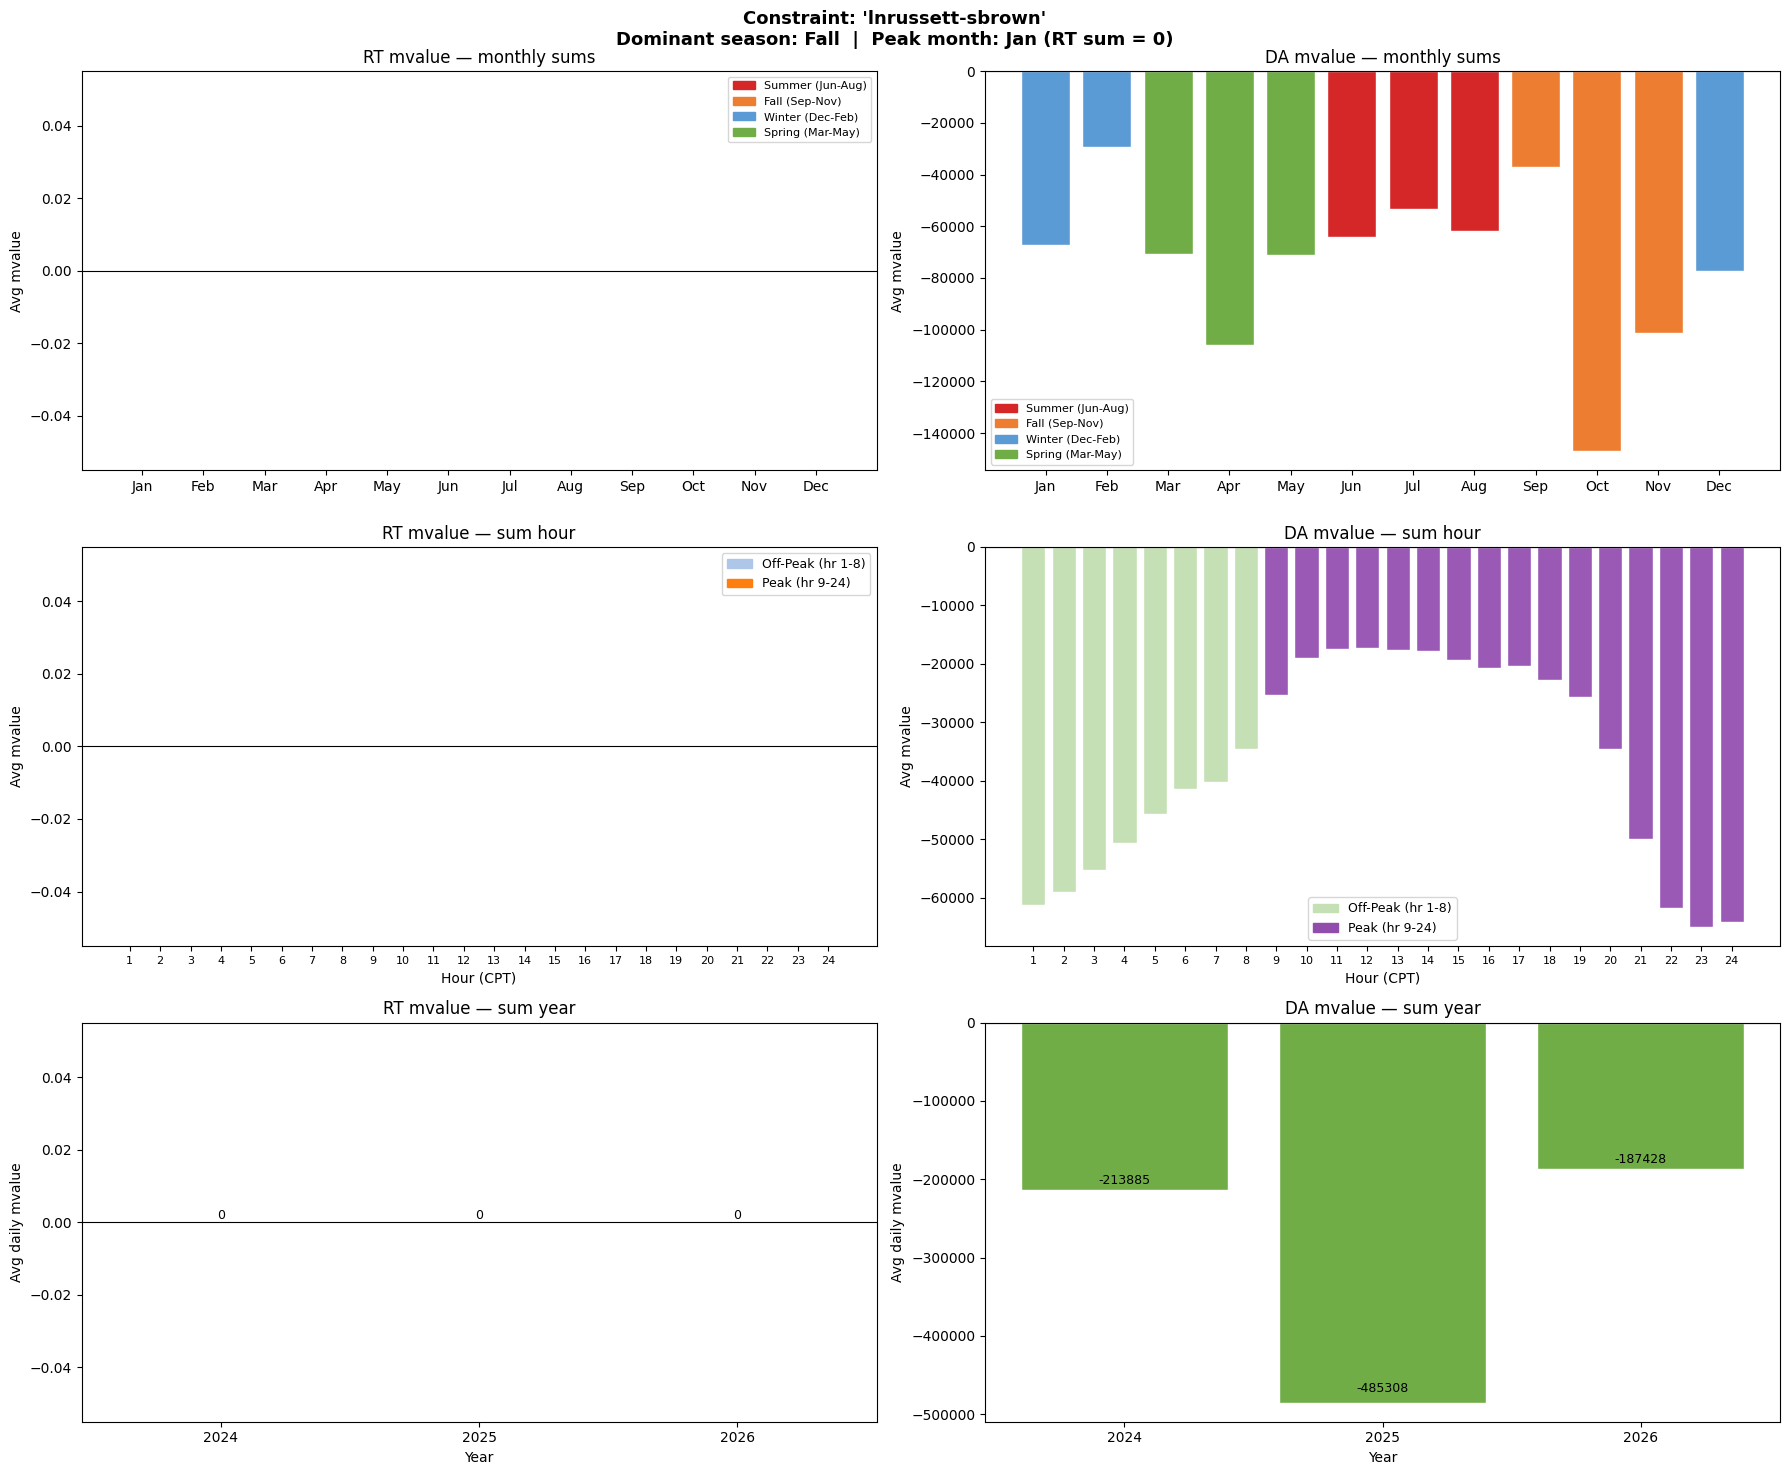

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -498647.14  |  off-peak (hr 1-8): -387974.32
'lnrussett-sbrown'  |  2026-06-05 → 2026-06-15  |  11 days


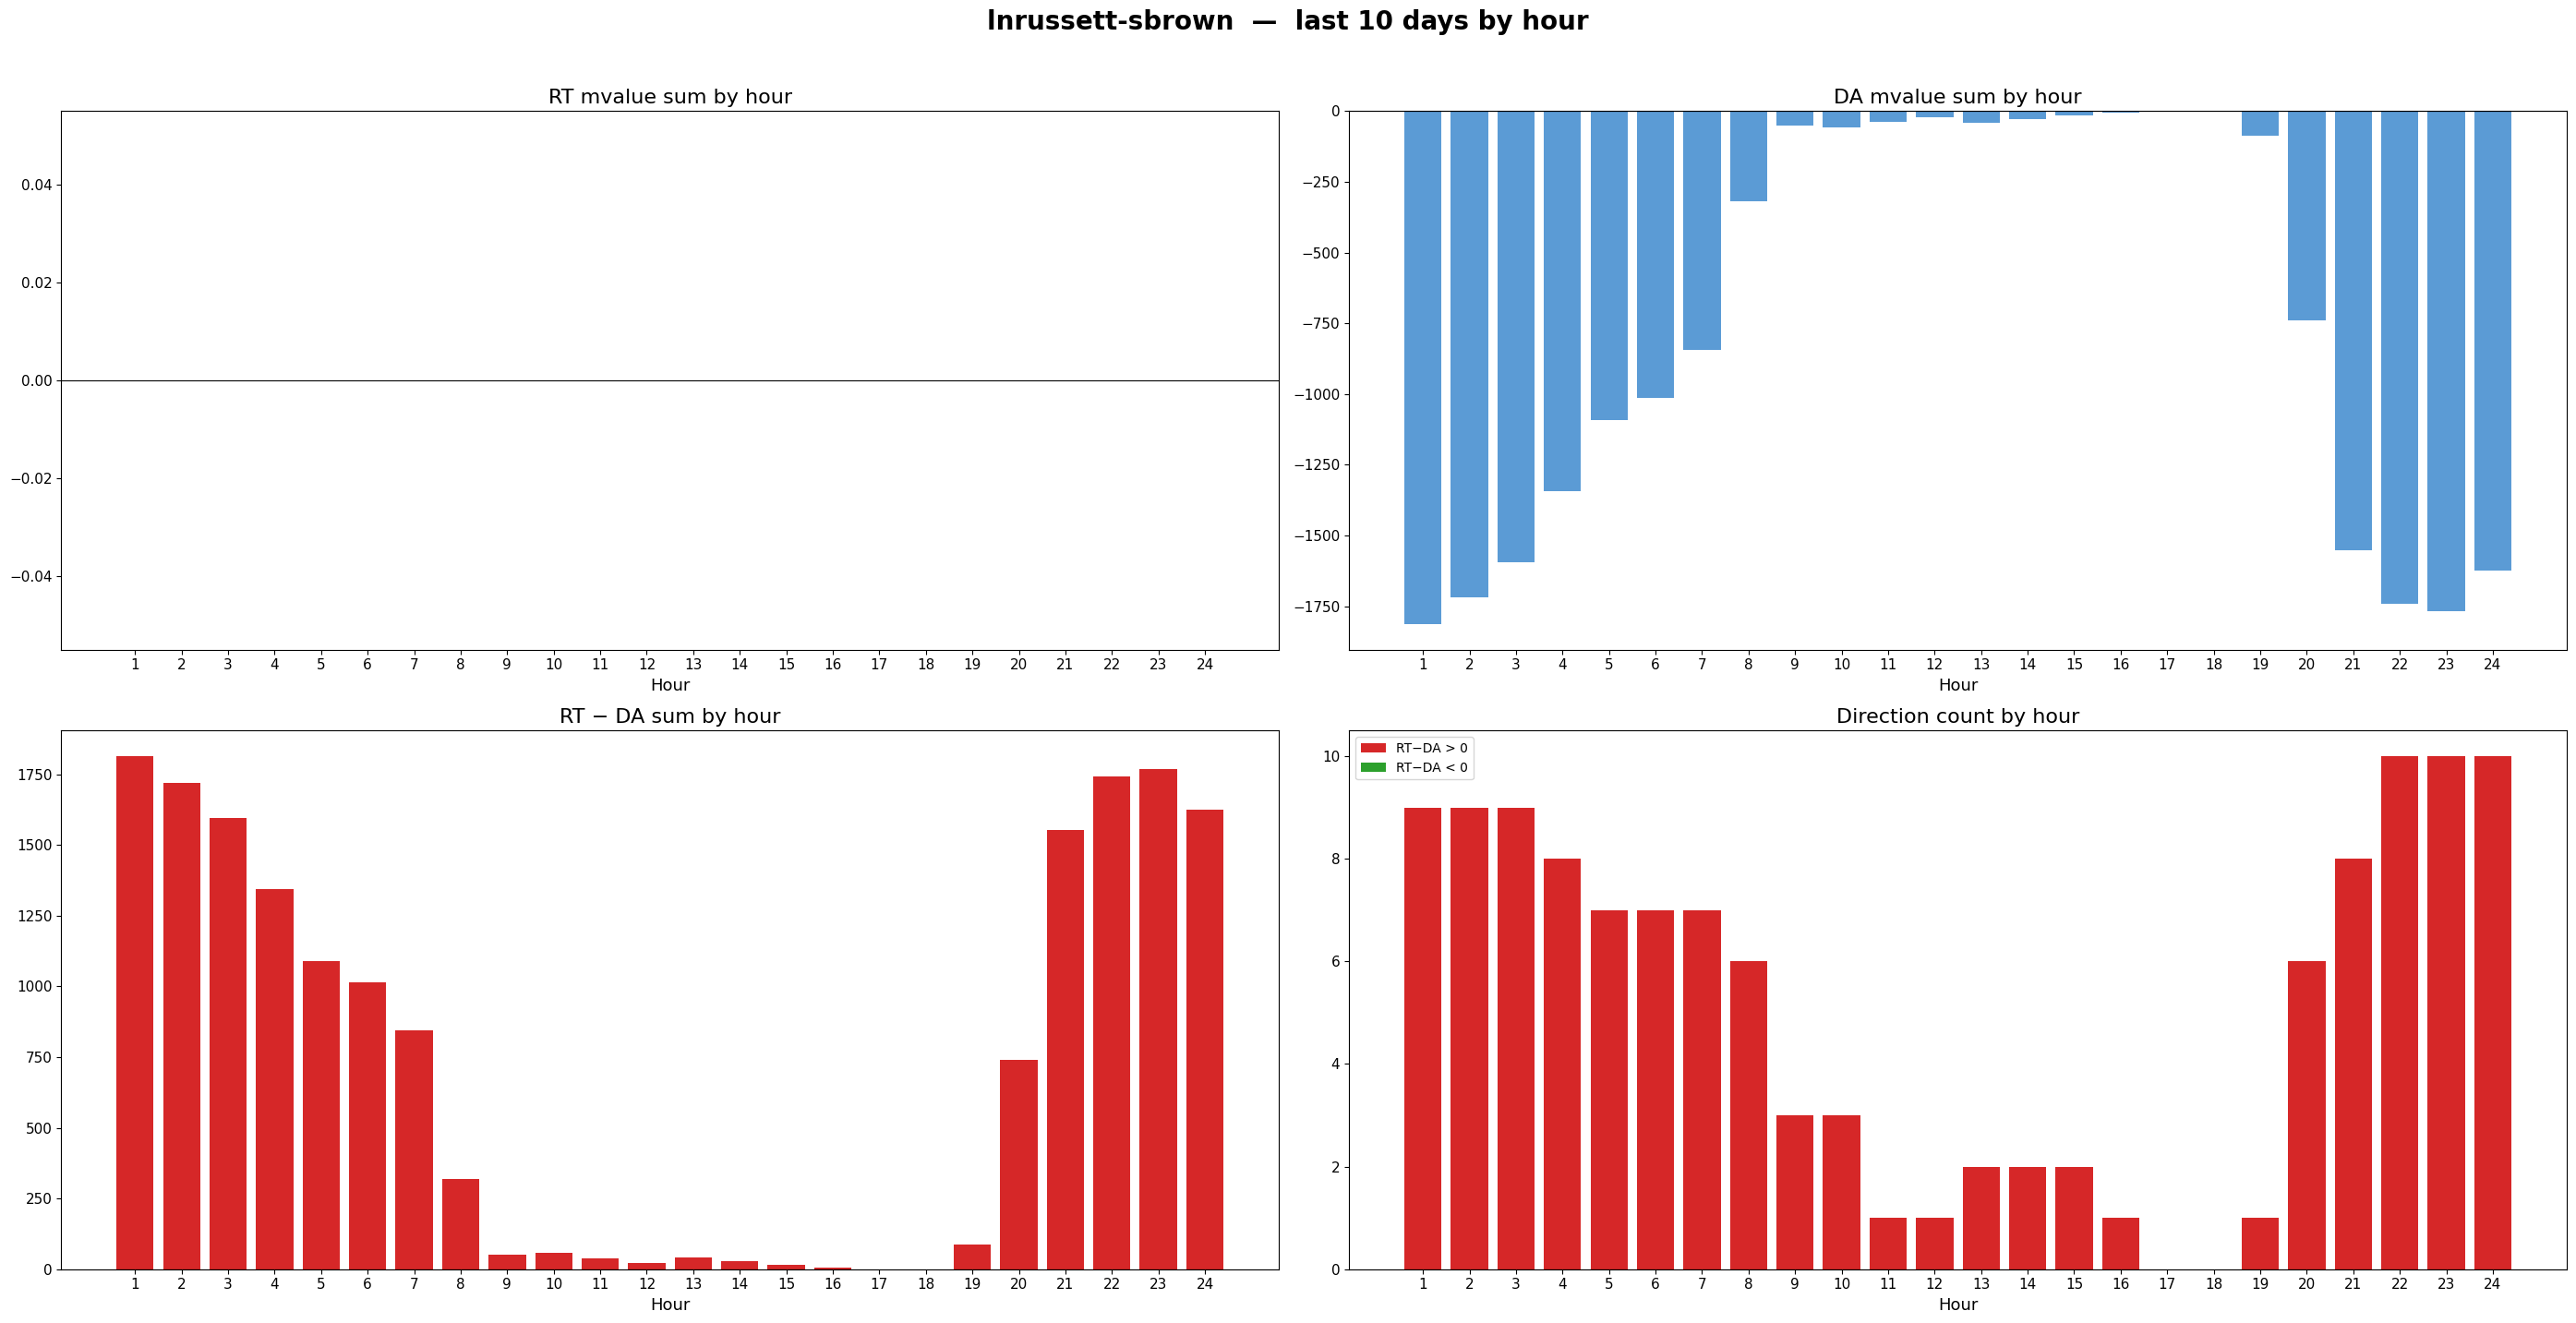


Total rows: 100836

  lnrussett-sbrown


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1384,-0.0960,0.079438,0.473439,15.246869,1.820213,5572.0
1,1499,0.4679,0.054893,0.654523,-74.312604,3.685014,5572.0
2,1532,0.4679,0.054408,0.655887,-74.096476,3.593539,5597.0
3,1533,0.4679,0.054408,0.655887,-74.096476,3.593539,5597.0
4,1229,-0.0646,0.045090,0.409505,10.230033,-2.659043,5597.0
5,492,-0.0539,0.022563,0.433804,8.535585,-1.957089,5597.0
6,1292,-0.0649,0.015984,0.449738,11.089571,-1.892101,2288.0
7,1038,0.0945,0.012014,0.614436,-14.964986,0.287487,5597.0
8,1475,0.0803,-0.014266,0.639092,-12.716279,-1.382525,5597.0
9,1734,0.4679,-0.020414,0.671578,-73.004155,4.742248,2579.0


In [5]:
from IPython.display import display, HTML
row_counts = hourly_mvalue.groupby('monitored').size().sort_values()
print(row_counts.to_string())

for name in row_counts.index:
    display(HTML(f'''
    <hr style="border: 3px solid black; margin: 30px 0;">
    <h1 style="background:#2c3e50; color:white; padding:12px 20px; border-radius:6px; font-family:monospace;">
        {name} &nbsp;<span style="font-size:0.6em; color:#aaa;">({row_counts[name]:,} rows)</span>
    </h1>
    <hr style="border: 1px solid #aaa; margin-bottom: 20px;">
    '''))

    analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, 4, 95)
    plot_constraint_seasonality(hourly_mvalue, name)
    plot_recent_hourly_distribution(hourly_mvalue, name, bid_dt, days=10)
    table = get_constraints_node_price(hourly_mvalue, dfax, [name])
    get_metrics_for_nodes(table)

In [6]:
# name = 'lnraun-tekamho'
# zone= 1
# analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 90)
# plot_constraint_seasonality(hourly_mvalue, name)
# table = get_constraints_node_price(hourly_mvalue, dfax, [name])
# get_metrics_for_nodes(table)

In [7]:
fundamentals = get_weather_date(hourly_mvalue, bid_dt)

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


In [8]:
tomorrow_pct = predict_tomorrow_percentile(fundamentals, bid_dt)


--- Zone 1 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,2615.8,100.0,4195.2,71.0
1,2,2581.5,100.0,4062.8,67.7
2,3,2538.2,100.0,3961.5,61.3
3,4,2417.7,100.0,3896.4,64.5
4,5,2105.3,90.3,3966.3,67.7
5,6,1659.4,74.2,4206.1,83.9
6,7,1493.1,74.2,4450.9,83.9
7,8,1604.1,77.4,4706.0,87.1
8,9,1748.4,90.3,4940.7,87.1
9,10,2186.7,100.0,5072.5,90.3



--- Zone 2 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,6261.3,100.0,712.6,87.1
1,2,6317.1,100.0,697.6,87.1
2,3,6283.4,100.0,690.6,90.3
3,4,6241.7,96.8,678.8,90.3
4,5,6204.1,96.8,683.2,90.3
5,6,6137.7,96.8,707.7,87.1
6,7,5938.8,93.5,738.3,90.3
7,8,5574.2,87.1,758.0,93.5
8,9,5042.9,87.1,797.3,90.3
9,10,4312.1,74.2,834.0,93.5



--- Zone 3 ---


...


--- Zone 5 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,2495.8,74.2,3681.3,83.9
1,2,2520.6,77.4,3580.0,67.7
2,3,2540.4,77.4,3575.4,77.4
3,4,2559.5,77.4,3573.0,80.6
4,5,2546.0,80.6,3586.4,74.2
5,6,2593.3,83.9,3629.8,67.7
6,7,2719.9,90.3,3722.0,58.1
7,8,2861.0,96.8,3883.8,64.5
8,9,3058.6,100.0,3924.0,58.1
9,10,3188.8,100.0,3979.9,58.1



--- Zone 21 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,947.9,100.0,2924.0,64.5
1,2,975.1,100.0,2797.1,67.7
2,3,981.4,100.0,2704.4,67.7
3,4,977.9,100.0,2636.0,67.7
4,5,968.4,100.0,2596.2,77.4
5,6,964.8,100.0,2576.0,71.0
6,7,964.5,96.8,2588.6,61.3
7,8,912.1,93.5,2613.4,45.2
8,9,836.3,93.5,2669.1,38.7
9,10,805.6,93.5,2738.2,38.7



--- Summary (median pct by zone / peak) ---
1: ow: 100, fw: 95, ol: 87, fl: 69
2: ow: 51, fw: 96, ol: 93, fl: 90
3: ow: 50, fw: 100, ol: 100, fl: 87
4: ow: 83, fw: 96, ol: 90, fl: 83
5: ow: 87, fw: 77, ol: 48, fl: 70
21: ow: 70, fw: 100, ol: 38, fl: 67
